In [120]:
import glob

import xarray as xr
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import intake
from distributed import Client
import h5py
import dask.array as da
from matplotlib import gridspec
import cartopy.crs as ccrs
import cmocean as cm

catalog = intake.cat.access_nri

In [8]:
#This cell must be in all notebooks!
#It allows us to run all the notebooks at once, note that the following cell has a tag "parameters" which allows us to pass in arguments externally using papermill (see mkfigs.sh for details)

#parameters

### USER EDIT start
#See the available cm3 experiment list here
#https://access-cm3-configs.readthedocs.io/Experiments/

esm_file='/g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-27-07-2026-PD-control/cm3-datastore/cm3-datastore.json'

dpi=300
### USER EDIT stop

import os
from matplotlib import rcParams
%matplotlib inline
rcParams['figure.dpi']= dpi

plotfolder=f"/g/data/{os.environ['PROJECT']}/{os.environ['USER']}/access-cm3-paper-figs/"
os.makedirs(plotfolder, exist_ok=True)

 # a similar cell under this means it's being run in batch
print("ESM datastore path: ",esm_file)
print("Plot folder path: ",plotfolder)

ESM datastore path:  /g/data/zv30/non-cmip/ACCESS-CM3/cm3-run-27-07-2026-PD-control/cm3-datastore/cm3-datastore.json
Plot folder path:  /g/data/tm70/kr4383/access-cm3-paper-figs/


In [11]:
client = Client(threads_per_worker=1)
print(client.dashboard_link)

/proxy/8787/status


In [12]:
COLUMNS_WITH_ITERABLES = [
        "variable",
        "variable_long_name",
        "variable_standard_name",
        "variable_cell_methods",
        "variable_units"
]

datastore = intake.open_esm_datastore(
    esm_file,
    columns_with_iterables=COLUMNS_WITH_ITERABLES
)

In [47]:
cm3_atm_fps = datastore.search(variable="fld_s01i208", frequency="1mon").df.sort_values(by='start_date').path.values
cm3_atm_ds_list = [h5py.File(fp, "r") for fp in cm3_atm_fps]

In [42]:
cm2_dir = '/g/data/p73/archive/non-CMIP/ACCESS-CM2/cj877/history/atm/netCDF'
cm2_atm_fp_list = [
    os.path.join(cm2_dir, f'cj877a.pm{str(year).zfill(4)}{str(month).zfill(2)}_mon.nc')
    for year in range(1, 51)
    for month in range(1, 13)
]

cm2_atm_ds_list = [h5py.File(fp, "r") for fp in cm2_atm_fp_list]

In [3]:
# CM3_atmos = xr.open_dataset('/g/data/x77/dd7103/access-cm3-paper-figs/CM3_atm_VARs_1981-2030.nc', decode_cf=False)
# CM3_atmos.coords['time'] = xr.date_range(start='1981-01-01', periods=600, freq='ME')

# CM2_atmos = xr.open_dataset('/g/data/x77/dd7103/access-cm3-paper-figs/CM2_atm_VARs_Year1-502.nc', decode_cf=False)
# CM2_atmos.coords['time'] = xr.date_range(start='1579-01-01', periods=6024, freq='ME')
# # Slice last 100 years (last 1200 months)
# CM2_atmos = CM2_atmos.isel(time=slice(-1200, None))

## CERES data

In [4]:
def available_variables(datastore):
    """Return a pandas dataframe summarising the variables in a datastore"""
    variable_columns = [col for col in datastore.df.columns if "variable" in col]
    return (
        datastore.df[variable_columns]
        .explode(variable_columns)
        .drop_duplicates()
        .set_index("variable")
        .sort_index()
    )

In [7]:
source_id = 'CERES-EBAF'
obs_dict = catalog['esmvaltool-obs-ct11'].search(source_id=source_id,variable_id = ('rlut','rsut','rlutcs','rsutcs'),time_range='200003-201605'
                                     ).to_dataset_dict(
                                                xarray_combine_by_coords_kwargs = dict(
                                                compat="override",
                                                data_vars="minimal",
                                                coords="minimal",
                                            ),
                                            xarray_open_kwargs = dict(
                                                use_cftime=True,
                                                chunks={},
                                            ),
                                        )


obs = xr.Dataset()
for ds_key, ds in obs_dict.items():
    for var in ('rlut','rsut','rlutcs','rsutcs'):
        if var in ds.data_vars:
            obs[var] = ds[var]

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/access_nri_intake/aliases.py:192: UserWarning: Value aliasing: variable_id='rlut' → variable_id=['fld_s03i332','rlut']
  norm: dict[str, Any] = self._normalise_kwargs(kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/access_nri_intake/aliases.py:192: UserWarning: Value aliasing: variable_id='rsut' → variable_id=['fld_s01i208','rsut']
  norm: dict[str, Any] = self._normalise_kwargs(kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/access_nri_intake/aliases.py:192: UserWarning: Value aliasing: variable_id='rlutcs' → variable_id=['fld_s02i206','rlutcs']
  norm: dict[str, Any] = self._normalise_kwargs(kwargs)
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.07/lib/python3.12/site-packages/access_nri_intake/aliases.py:192: UserWarning: Value aliasing: variable_id='rsutcs' → variable_id=['fld_s01i209','rsutcs']
  norm: 


--> The keys in the returned dictionary of datasets are constructed as follows:
	'project_id.source_id.experiment_id.version.table_id.variable_id.tier.institution_id'


## Cloud Radiative Effect (CRE)

In [49]:
atm_xr_ds_sample = xr.open_dataset(cm3_atm_fps[0])

In [50]:
def get_atm_data_monthly(atm_ds_list, name):
    # use monthly dataset to get dimensions
    dims = atm_xr_ds_sample[name].dims
    # concatenate data
    darr = xr.DataArray(da.concatenate([da.from_array(ds[f"/{name}"]) for ds in atm_ds_list]), dims=dims)
    
    # use monthly dataset to get spatial coordinates
    atm_coords = dict((dim, atm_xr_ds_sample[name].coords[dim].data) for dim in dims)
    # calculate time coordinates assuming monthly means
    first_month = atm_coords['time'][0].astype("datetime64[M]")
    months = first_month + np.arange(len(atm_fps))
    month_starts = months.astype("datetime64[ns]")
    next_month_starts = (months + 1).astype("datetime64[ns]")
    half_month = (next_month_starts - month_starts) // 2
    atm_coords['time'] = month_starts + half_month
    
    # assign coordinates
    darr = darr.assign_coords(atm_coords)
    return darr

In [57]:
SW_CRE_CM3 =  get_atm_data_monthly(cm3_atm_ds_list, "fld_s01i209") - get_atm_data_monthly(cm3_atm_ds_list, "fld_s01i208")
LW_CRE_CM3 =  get_atm_data_monthly(cm3_atm_ds_list, "fld_s02i206") - get_atm_variable(cm3_atm_ds_list, "fld_s02i205")

SW_CRE_CM3 = SW_CRE_CM3.compute()
LW_CRE_CM3 = LW_CRE_CM3.compute();

In [58]:
SW_CRE_CM2 =  get_atm_data_monthly(cm2_atm_ds_list, "fld_s01i209") - get_atm_data_monthly(cm2_atm_ds_list, "fld_s01i208")
LW_CRE_CM2 =  get_atm_data_monthly(cm2_atm_ds_list, "fld_s02i206") - get_atm_data_monthly(cm2_atm_ds_list, "fld_s02i205")

SW_CRE_CM2 = SW_CRE_CM2.compute()
LW_CRE_CM2 = LW_CRE_CM2.compute();

In [ ]:
# CM3_atmos = xr.open_dataset('/g/data/x77/dd7103/access-cm3-paper-figs/CM3_atm_VARs_1981-2030.nc', decode_cf=False)
# CM3_atmos.coords['time'] = xr.date_range(start='1981-01-01', periods=600, freq='ME')

# CM2_atmos = xr.open_dataset('/g/data/x77/dd7103/access-cm3-paper-figs/CM2_atm_VARs_Year1-502.nc', decode_cf=False)
# CM2_atmos.coords['time'] = xr.date_range(start='1579-01-01', periods=6024, freq='ME')
# # Slice last 100 years (last 1200 months)
# CM2_atmos = CM2_atmos.isel(time=slice(-1200, None))

In [186]:
CM3_atmos = xr.Dataset({
    'SW_CRE': SW_CRE_CM3,
    'LW_CRE': LW_CRE_CM3
})

CM2_atmos = xr.Dataset({
    'SW_CRE': SW_CRE_CM2,
    'LW_CRE': LW_CRE_CM2
})

## Regrid CERES variables 

In [61]:
SW_CRE_CERES = obs['rsutcs'] - obs['rsut'] 
LW_CRE_CERES = obs['rlutcs'] - obs['rlut']

# Combine into a Dataset
CRE_CERES = xr.Dataset({
    'SW_CRE': SW_CRE_CERES,
    'LW_CRE': LW_CRE_CERES
})

import xesmf as xe
ds_CM3 = CM3_atmos 
# Create regridder (use one DataArray to define grid mapping)
regridder = xe.Regridder(CRE_CERES, ds_CM3, 'bilinear', periodic=True, reuse_weights=False)

# Create a new Dataset for regridded variables
CRE_CERES_on_CM3 = xr.Dataset()

# Loop through each variable and regrid
for var in CRE_CERES.data_vars:
    CRE_CERES_on_CM3[var] = regridder(CRE_CERES[var])

## Function to calculate annual, seasonal mean CRE

In [62]:
def CRE_Var(da, weights):
    """
    Compute CRE statistics including:
      - Annually varying global mean time series
      - Annual global mean 
      - Seasonally varying (DJF/MAM/JJA/SON) global means
      - Seasonal global mean 
      - Annual mean map (lat-lon)
      - Seasonal mean map (lat-lon)
    """

    # Annually varying (time series)
    annual_ts = da.groupby("time.year").mean("time").weighted(weights).mean(("lat", "lon"))

    # Annual global mean
    annual_mean = annual_ts.mean("year")
    
    # Annual mean map
    annual_map = da.groupby('time.year').mean('time').mean('year')

    # Seasonally varying time series variables (DJF, MAM, JJA, SON)
    seasonal_ts = da.groupby("time.season").mean("time").weighted(weights).mean(("lat", "lon"))

    # Seasonal global mean
    seasonal_mean = seasonal_ts.mean("season")
    # Seasonal mean maps
    seasonal_map = da.groupby("time.season").mean("time")

    # Annual zonal mean (latitude x year)
    zonal_annual = da.groupby("time.year").mean("time").mean("year").weighted(weights).mean("lon")
    # Seasonal zonal mean (latitude x season)
    zonal_seasonal = da.groupby("time.season").mean("time").weighted(weights).mean("lon")
    
    return {
        "annual_ts": annual_ts,
        "annual_mean": annual_mean,
        "annual_map": annual_map,
        "seasonal_map": seasonal_map,
        "zonal_annual": zonal_annual,
        "zonal_seasonal": zonal_seasonal
    }

In [63]:
weights = np.cos(np.deg2rad(SW_CRE_CM3.lat))
weights.name = "weights"

SWCRE_CM3_stats = CRE_Var(SW_CRE_CM3, weights)
SWCRE_CM2_stats = CRE_Var(SW_CRE_CM2, weights)
SWCRE_CERES_stats = CRE_Var(CRE_CERES_on_CM3.SW_CRE, weights)

LWCRE_CM3_stats = CRE_Var(LW_CRE_CM3, weights)
LWCRE_CM2_stats = CRE_Var(LW_CRE_CM2, weights)
LWCRE_CERES_stats = CRE_Var(CRE_CERES_on_CM3.LW_CRE, weights)


## Annual evoluation of global mean CRE components 

In [64]:
# Total = SW + LW
TOT_CM3_annual_ts  = SWCRE_CM3_stats["annual_ts"]  + LWCRE_CM3_stats["annual_ts"]
TOT_CM2_annual_ts  = SWCRE_CM2_stats["annual_ts"]  + LWCRE_CM2_stats["annual_ts"]
TOT_CERES_annual_ts = SWCRE_CERES_stats["annual_ts"] + LWCRE_CERES_stats["annual_ts"]

# global means
mean_SW_CERES = SWCRE_CERES_stats["annual_mean"].compute()
mean_SW_CM3   = SWCRE_CM3_stats["annual_mean"]
mean_SW_CM2   = SWCRE_CM2_stats["annual_mean"]
mean_LW_CERES = LWCRE_CERES_stats["annual_mean"].compute()
mean_LW_CM3   = LWCRE_CM3_stats["annual_mean"]
mean_LW_CM2   = LWCRE_CM2_stats["annual_mean"]
mean_TOT_CERES = mean_SW_CERES + mean_LW_CERES
mean_TOT_CM3   = mean_SW_CM3 + mean_LW_CM3
mean_TOT_CM2   = mean_SW_CM2 + mean_LW_CM2

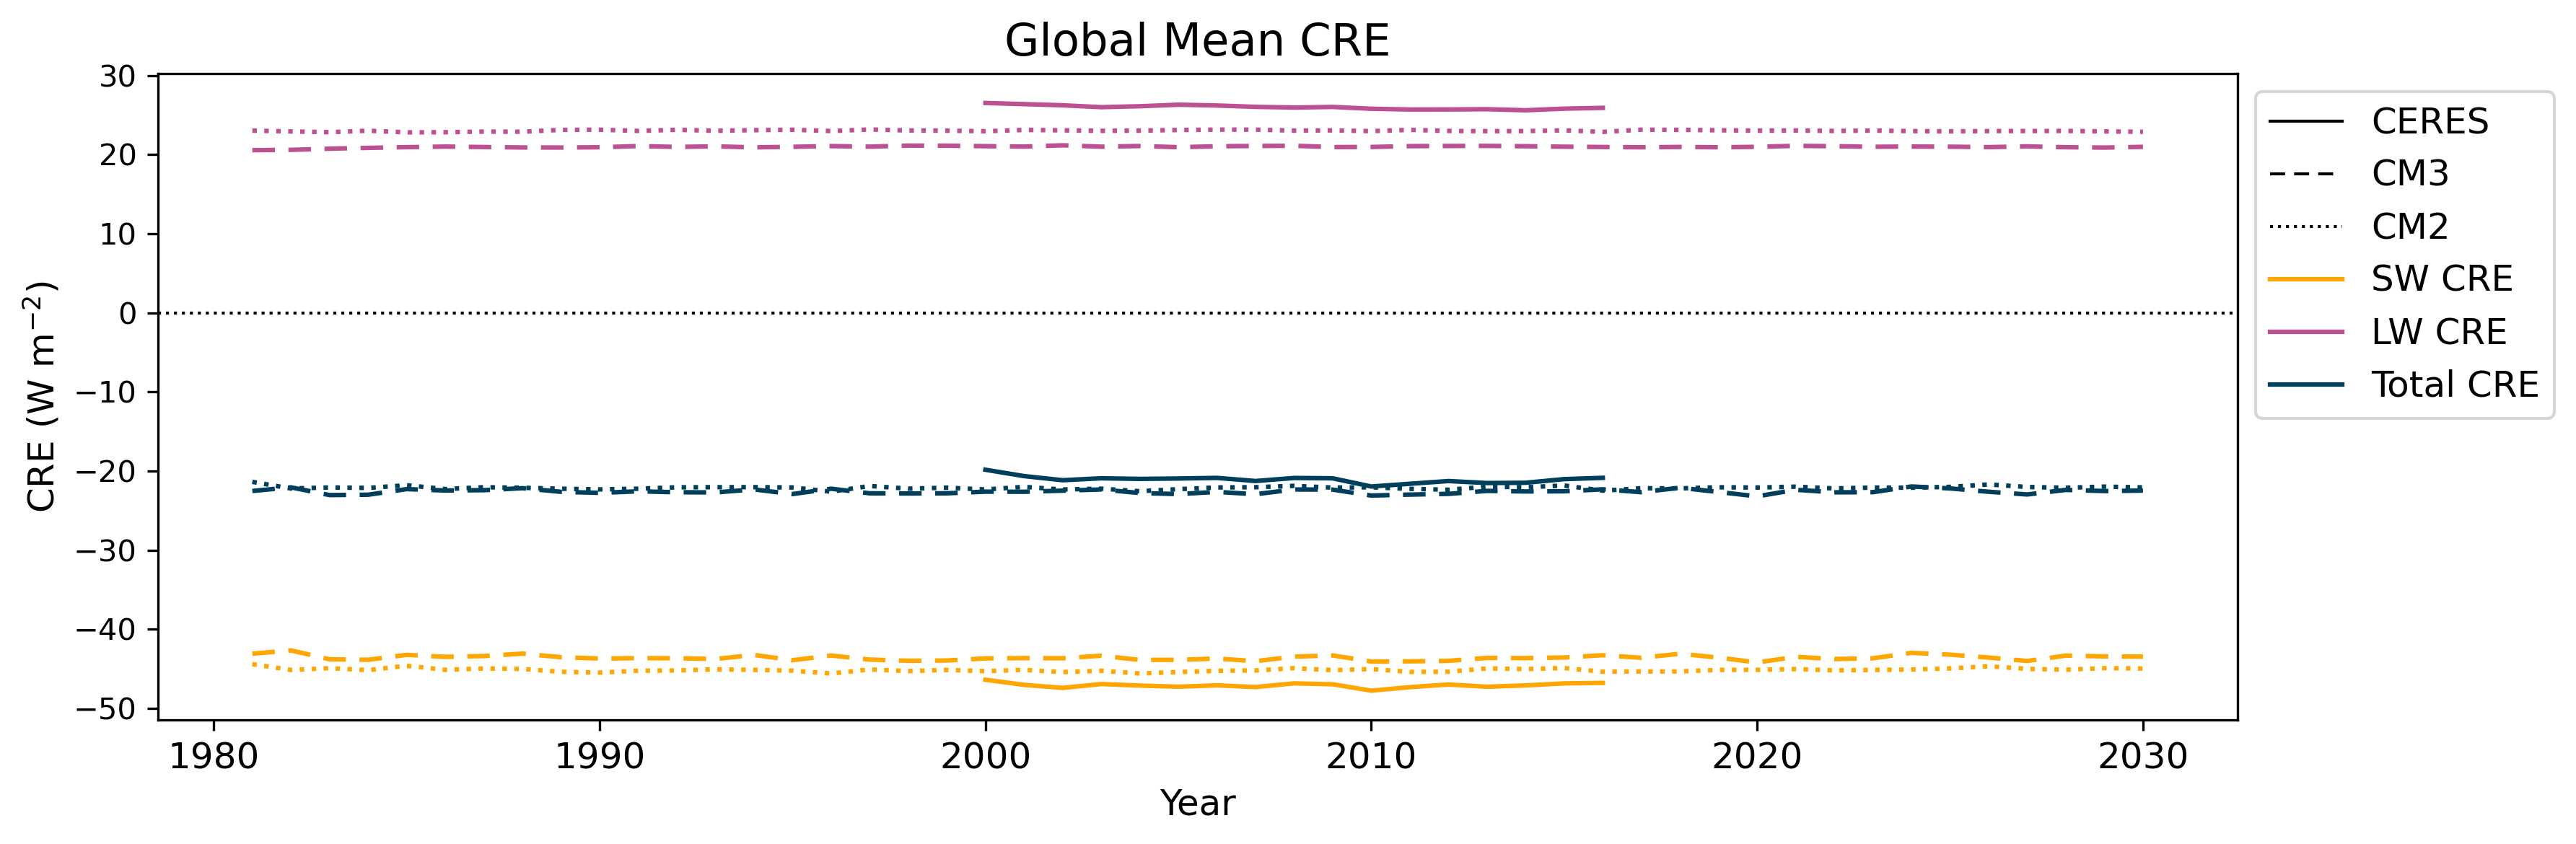

In [65]:
fig, ax = plt.subplots(figsize=(12, 4))

# Colors
cSW  = "#ffa600"
cLW  = "#bc5090"
cTOT = "#003f5c"

# ANNUAL SW CRE
ax.axhline(y=0, color='k', lw=1., ls=':')

ax.plot(TOT_CERES_annual_ts.year, TOT_CERES_annual_ts, color='k', lw=1., label="CERES")
ax.plot(TOT_CERES_annual_ts.year, TOT_CERES_annual_ts, color='k', linestyle=(0, (5, 3)), lw=1., label="CM3")
ax.plot(TOT_CERES_annual_ts.year, TOT_CERES_annual_ts, color='k', linestyle=':', lw=1., label="CM2")

# CERES
ax.plot(SWCRE_CERES_stats["annual_ts"].year, SWCRE_CERES_stats["annual_ts"], color=cSW, lw=1.5, label="SW CRE")
# CM3 (dashed)
ax.plot(SWCRE_CM3_stats["annual_ts"].year, SWCRE_CM3_stats["annual_ts"], color=cSW, lw=1.5, linestyle=(0, (5, 3)))
# CM2 (dotted)
ax.plot(SWCRE_CM2_stats["annual_ts"].year, SWCRE_CM2_stats["annual_ts"], color=cSW, lw=1.5, linestyle=':')

# ANNUAL LW CRE
ax.plot(LWCRE_CERES_stats["annual_ts"].year, LWCRE_CERES_stats["annual_ts"], color=cLW, lw=1.5, label="LW CRE")
ax.plot(LWCRE_CM3_stats["annual_ts"].year, LWCRE_CM3_stats["annual_ts"], color=cLW, lw=1.5, linestyle=(0, (5, 3)))
ax.plot(LWCRE_CM2_stats["annual_ts"].year, LWCRE_CM2_stats["annual_ts"], color=cLW, lw=1.5, linestyle=':')

# ANNUAL TOTAL CRE
ax.plot(TOT_CERES_annual_ts.year, TOT_CERES_annual_ts, color=cTOT, lw=1.5, label="Total CRE")
ax.plot(TOT_CM3_annual_ts.year, TOT_CM3_annual_ts, color=cTOT, lw=1.5, linestyle=(0, (5, 3)))
ax.plot(TOT_CM2_annual_ts.year, TOT_CM2_annual_ts, color=cTOT, lw=1.5, linestyle=':')

# Titles and labels
ax.set_title("Global Mean CRE", fontsize=15)
ax.set_ylabel("CRE (W m$^{-2}$)", fontsize=12)
ax.set_xlabel("Year", fontsize=12)
ax.tick_params(axis='x', labelsize=12)

# Legend 
ax.legend(loc='upper left', bbox_to_anchor=(1., 1), fontsize=12)

plt.tight_layout()
plt.show()


## Latitudinally varying CRE plots 

## Annual mean plots

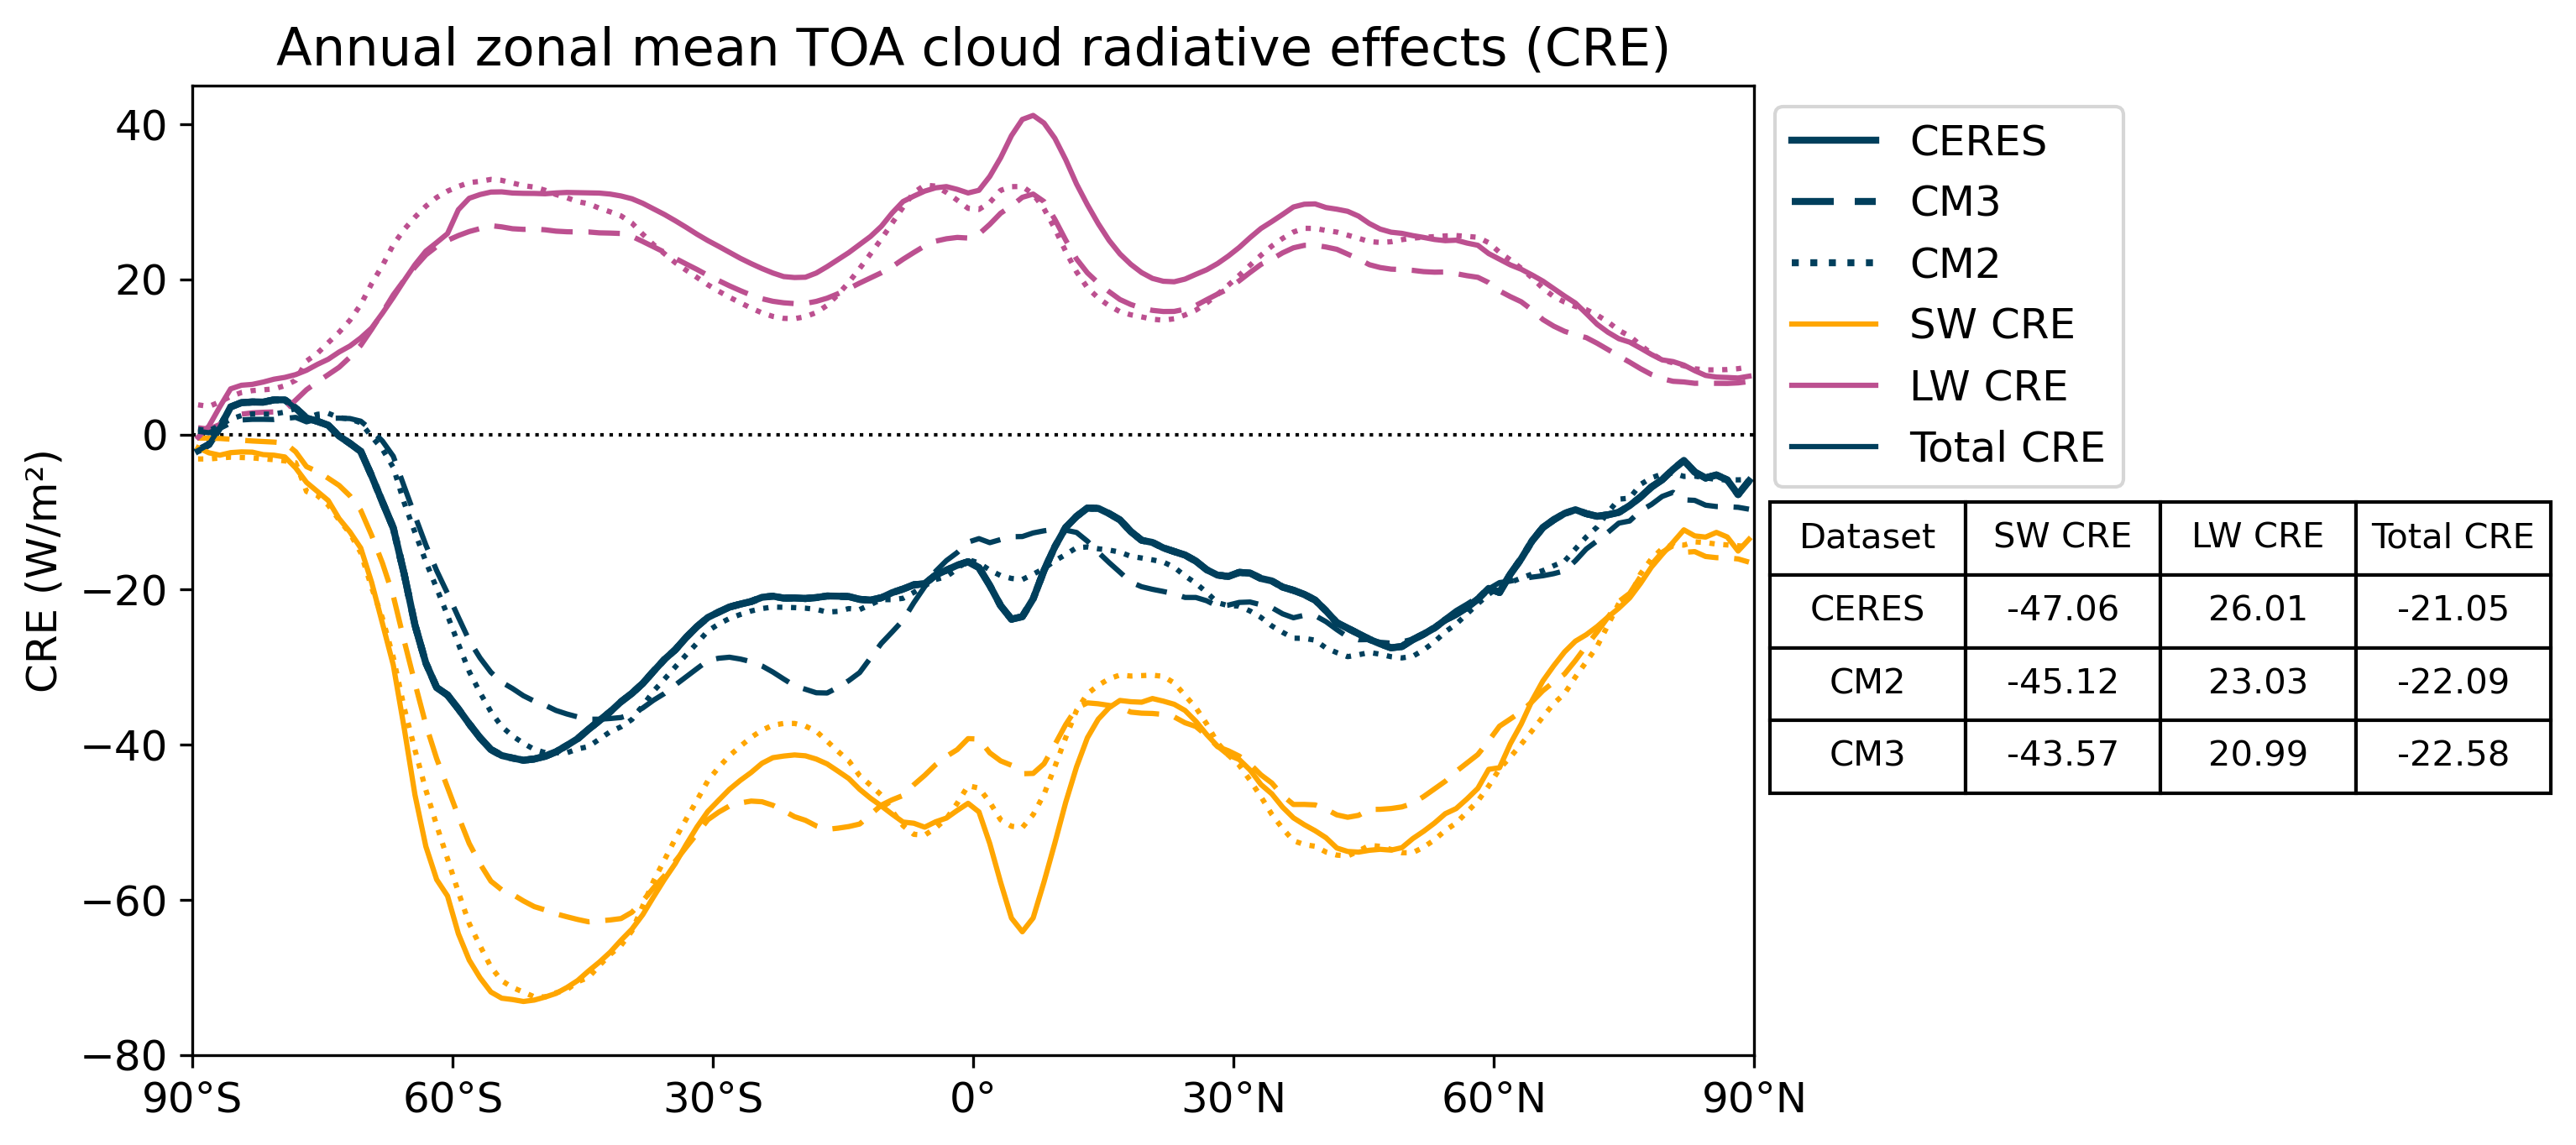

In [66]:

# -----------------------
# Colors and seasons
# -----------------------
seasons = ["DJF", "MAM", "JJA", "SON"]
cSW  = "#ffa600"
cLW  = "#bc5090"
cTOT = "#003f5c"

# Total
TOT_CERES_zonal_annual = SWCRE_CERES_stats["zonal_annual"] + LWCRE_CERES_stats["zonal_annual"]
TOT_CM3_zonal_annual   = SWCRE_CM3_stats["zonal_annual"] + LWCRE_CM3_stats["zonal_annual"]
TOT_CM2_zonal_annual   = SWCRE_CM2_stats["zonal_annual"] + LWCRE_CM2_stats["zonal_annual"]

lat = TOT_CM3_zonal_annual.lat

# Create figure
fig, axs = plt.subplots(1, 1, figsize=(8, 5), gridspec_kw={'wspace': 0.1, 'hspace': 0.25})
ax = axs
ax.axhline(y=0, color='k', lw=1., ls=':')

ax.plot(lat, TOT_CERES_zonal_annual, color=cTOT, lw=2, label="CERES")
ax.plot(lat, TOT_CERES_zonal_annual, color=cTOT, lw=2, linestyle=(0, (6, 3)), label="CM3")
ax.plot(lat, TOT_CERES_zonal_annual, color=cTOT, lw=2, linestyle=":", label="CM2")

# SW
ax.plot(lat, SWCRE_CERES_stats["zonal_annual"], color=cSW, lw=1.5, label="SW CRE")
ax.plot(lat, SWCRE_CM3_stats["zonal_annual"], color=cSW, lw=1.5, linestyle=(0, (6, 3)), )
ax.plot(lat, SWCRE_CM2_stats["zonal_annual"], color=cSW, lw=1.5, linestyle=':', )

# LW
ax.plot(lat, LWCRE_CERES_stats["zonal_annual"], color=cLW, lw=1.5, label="LW CRE")
ax.plot(lat, LWCRE_CM3_stats["zonal_annual"], color=cLW, lw=1.5, linestyle=(0, (6, 3)), )
ax.plot(lat, LWCRE_CM2_stats["zonal_annual"], color=cLW, lw=1.5, linestyle=':',)

# Total
ax.plot(lat, TOT_CERES_zonal_annual, color=cTOT, lw=1.5, label="Total CRE")
ax.plot(lat, TOT_CM3_zonal_annual, color=cTOT, lw=1.5, linestyle=(0, (6, 3)))
ax.plot(lat, TOT_CM2_zonal_annual, color=cTOT, lw=1.5, linestyle=':')

ax.set_title("Annual zonal mean TOA cloud radiative effects (CRE)", fontsize=15)
ax.set_ylabel("CRE (W/m²)", fontsize=12)
ax.set_ylim(-80, 45)       # top row y-limit
ax.set_xlim(-90, 90)       # x-axis limit


# Customize x-axis ticks for all visible axes
xticks = np.arange(-90, 91, 30)
xtick_labels = [f"{abs(x)}°S" if x < 0 else (f"{x}°" if x == 0 else f"{x}°N") for x in xticks]
ax.set_xticks(xticks)
ax.set_xticklabels(xtick_labels, fontsize=12, rotation=0)
ax.tick_params(axis='y', labelsize=12)

# Place legend outside the annual plot
axs.legend(bbox_to_anchor=(1.0, 1), loc='upper left', fontsize=12)

# Table data
cell_text = [
    ["CERES", f"{mean_SW_CERES:.2f}", f"{mean_LW_CERES:.2f}", f"{mean_TOT_CERES:.2f}"],
    ["CM2",   f"{mean_SW_CM2:.2f}",   f"{mean_LW_CM2:.2f}",   f"{mean_TOT_CM2:.2f}"],
    ["CM3",   f"{mean_SW_CM3:.2f}",   f"{mean_LW_CM3:.2f}",   f"{mean_TOT_CM3:.2f}"]
]
columns = ["Dataset", "SW CRE", "LW CRE", "Total CRE"]

# Add table next to legend
table = ax.table(cellText=cell_text, colLabels=columns,
                 bbox=[1.01, 0.27, .5, 0.3],  # [x0, y0, width, height] in axes coords
                 cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
plt.show()

## Seasonal mean plots

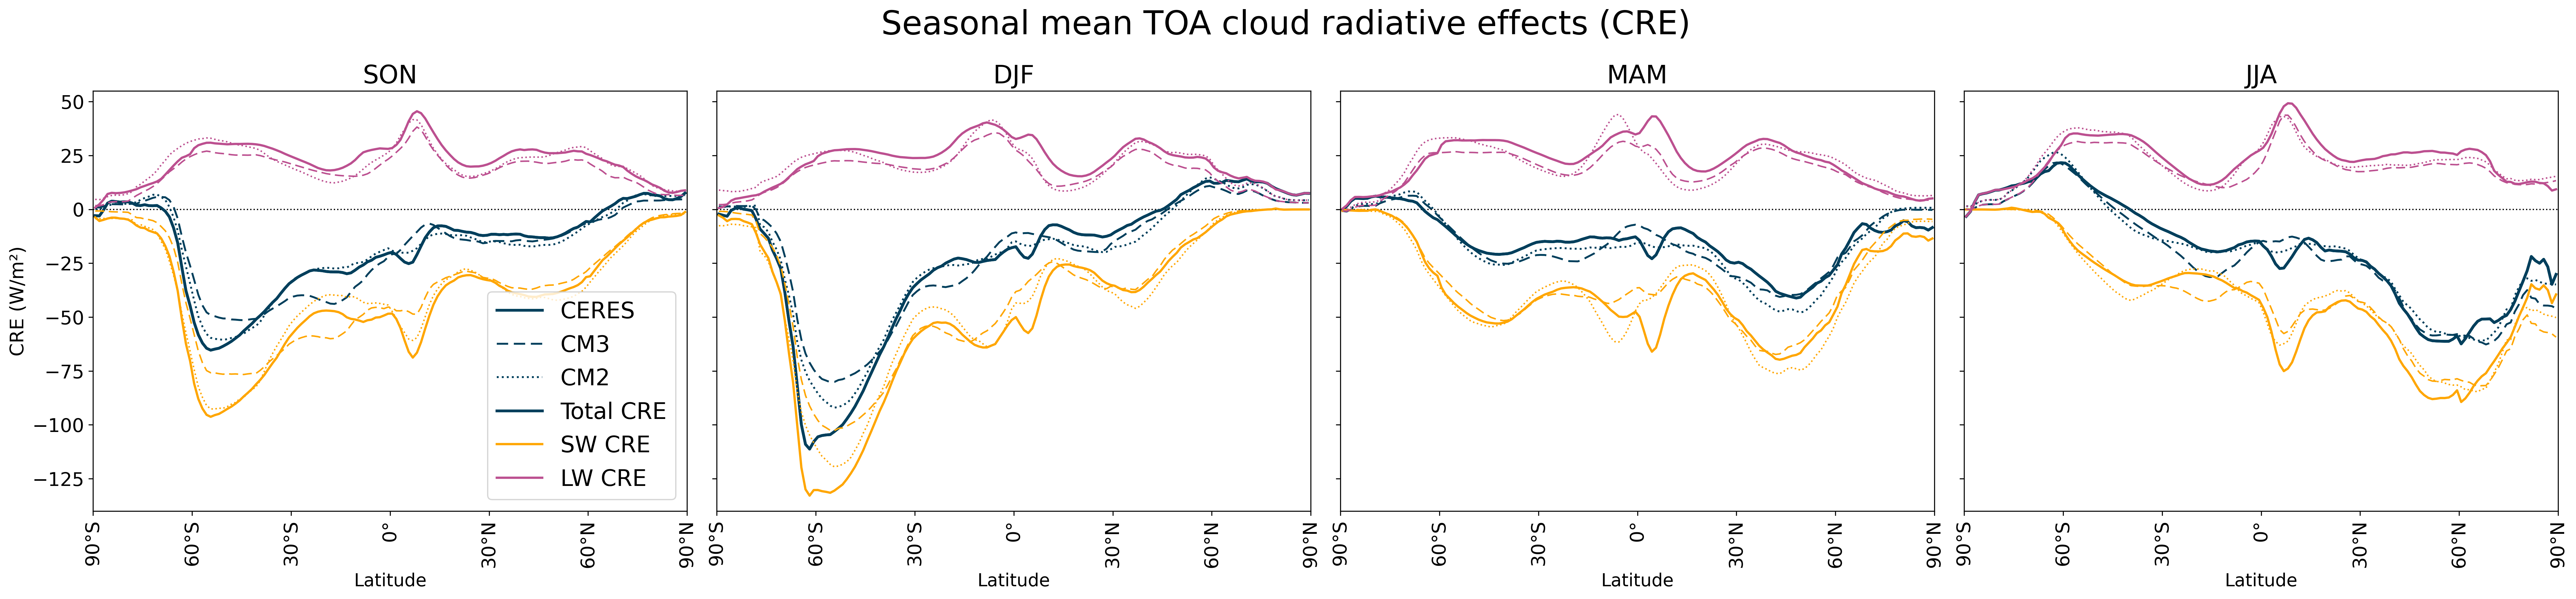

In [67]:

# Colors and seasons
seasons = ["SON", "DJF", "MAM", "JJA"]
cSW  = "#ffa600"
cLW  = "#bc5090"
cTOT = "#003f5c"

lat = SWCRE_CERES_stats["zonal_seasonal"].lat

fig, axs = plt.subplots(
    1, 4, figsize=(35, 6),
    gridspec_kw={'wspace': 0.05, 'hspace': 0.}
)

# Seasonal zonal means SON–JJA
for i, season in enumerate(seasons):
    ax = axs[i]
    ax.axhline(y=0, color='k', lw=1., ls=':')

    # Total CRE
    TOT_CERES_seasonal = (
        SWCRE_CERES_stats["zonal_seasonal"].sel(season=season)
        + LWCRE_CERES_stats["zonal_seasonal"].sel(season=season)
    )
    TOT_CM3_seasonal = (
        SWCRE_CM3_stats["zonal_seasonal"].sel(season=season)
        + LWCRE_CM3_stats["zonal_seasonal"].sel(season=season)
    )
    TOT_CM2_seasonal = (
        SWCRE_CM2_stats["zonal_seasonal"].sel(season=season)
        + LWCRE_CM2_stats["zonal_seasonal"].sel(season=season)
    )

    ax.plot(lat, TOT_CERES_seasonal, color=cTOT, lw=2.2, label="CERES")
    ax.plot(lat, TOT_CM3_seasonal, color=cTOT, lw=1.5, linestyle=(0, (6, 3)), label="CM3")
    ax.plot(lat, TOT_CM2_seasonal, color=cTOT, lw=1.5, linestyle=":", label="CM2")
    ax.plot(lat, TOT_CERES_seasonal, color=cTOT, lw=2.2, label="Total CRE")

    # SW CRE
    ax.plot(lat, SWCRE_CERES_stats["zonal_seasonal"].sel(season=season),
            color=cSW, lw=1.8, label="SW CRE")
    ax.plot(lat, SWCRE_CM3_stats["zonal_seasonal"].sel(season=season),
            color=cSW, lw=1.2, linestyle=(0, (6, 3)),)
    ax.plot(lat, SWCRE_CM2_stats["zonal_seasonal"].sel(season=season),
            color=cSW, lw=1.2, linestyle=":", )

    # LW CRE
    ax.plot(lat, LWCRE_CERES_stats["zonal_seasonal"].sel(season=season),
            color=cLW, lw=1.8, label="LW CRE")
    ax.plot(lat, LWCRE_CM3_stats["zonal_seasonal"].sel(season=season),
            color=cLW, lw=1.2, linestyle=(0, (6, 3)))
    ax.plot(lat, LWCRE_CM2_stats["zonal_seasonal"].sel(season=season),
            color=cLW, lw=1.2, linestyle=":")

    ax.set_title(season, fontsize=20)
    ax.set_xlabel("Latitude", fontsize=14)
    ax.set_ylim(-140, 55)
    ax.set_xlim(-90, 90)

# Tick formatting
xticks = np.arange(-90, 91, 30)
xtick_labels = [
    f"{abs(x)}°S" if x < 0 else ("0°" if x == 0 else f"{x}°N")
    for x in xticks
]

for ax in axs:
    ax.set_xticks(xticks)
    ax.set_xticklabels(xtick_labels, fontsize=15, rotation=90)
    ax.tick_params(axis='y', labelsize=15)

for i in [1, 2, 3]:
    axs[i].set_yticklabels([])
axs[0].set_ylabel("CRE (W/m²)", fontsize=15)
axs[0].legend(loc='lower right', fontsize=18)

fig.suptitle("Seasonal mean TOA cloud radiative effects (CRE)", fontsize=26, y=1.03)
plt.show()


## Maps of CRE in CERES obs and anomalies from CM2 and CM3

In [193]:
ceres_list = [CRE_CERES_on_CM3['LW_CRE'].mean(dim='time').compute(), CRE_CERES_on_CM3['SW_CRE'].mean(dim='time').compute()]
ceres_list.append(ceres_list[0] + ceres_list[1])

anom_cm3_list = [CM3_atmos['LW_CRE'].mean(dim='time').compute() - ceres_list[0], CM3_atmos['SW_CRE'].mean(dim='time').compute() - ceres_list[1]]
anom_cm3_list.append(anom_cm3_list[0] + anom_cm3_list[1])

anom_cm2_list = [CM2_atmos['LW_CRE'].mean(dim='time').compute() - ceres_list[0], CM2_atmos['SW_CRE'].mean(dim='time').compute() - ceres_list[1]]
anom_cm2_list.append(anom_cm2_list[0] + anom_cm2_list[1])

In [194]:
# Table data
ceres_gm = [float(darr.weighted(weights).mean().compute().data) for darr in ceres_list]
anom_cm2_gm = [float(darr.weighted(weights).mean().compute().data) for darr in anom_cm2_list]
anom_cm3_gm = [float(darr.weighted(weights).mean().compute().data) for darr in anom_cm3_list]

anom_cm2_rms = [np.sqrt(float((darr**2).weighted(weights).mean().compute().data)) for darr in anom_cm2_list]
anom_cm3_rms = [np.sqrt(float((darr**2).weighted(weights).mean().compute().data)) for darr in anom_cm3_list]

In [195]:
lw_norm = Normalize(vmin=0, vmax=80)
sw_norm = Normalize(vmin=-100, vmax=10)
tot_norm = Normalize(vmin=-80, vmax=20)

lw_anom_norm = Normalize(vmin=-35, vmax=35)
sw_anom_norm = Normalize(vmin=-40, vmax=40)
tot_anom_norm = Normalize(vmin=-35, vmax=35)

ceres_norms = [lw_norm, sw_norm, tot_norm]
anom_norm_dict = {"LW": lw_anom_norm, "SW": sw_anom_norm, "TOT": tot_anom_norm}

lw_cmap = sw_cmap = tot_cmap = cm.cm.thermal
lw_anom_cmap = sw_anom_cmap = tot_anom_cmap = 'RdBu_r'

ceres_cmaps = [lw_cmap, sw_cmap, tot_cmap]
anom_cmap_dict = {"LW": lw_anom_cmap, "SW": sw_anom_cmap, "TOT": tot_anom_cmap}

lw_anom_levels = np.linspace(lw_anom_norm.vmin, lw_anom_norm.vmax, int((lw_anom_norm.vmax - lw_anom_norm.vmin) // 5) + 1)
sw_anom_levels = np.linspace(sw_anom_norm.vmin, sw_anom_norm.vmax, int((sw_anom_norm.vmax - sw_anom_norm.vmin) // 5) + 1)
tot_anom_levels = np.linspace(tot_anom_norm.vmin, tot_anom_norm.vmax, int((tot_anom_norm.vmax - tot_anom_norm.vmin) // 5) + 1)

anom_levels_all = [lw_anom_levels, sw_anom_levels, tot_anom_levels]

In [196]:
# lw_anom_levels = np.linspace(lw_anom_norm.vmin, -5, int((-5 - lw_anom_norm.vmin) // 5) + 1)
# lw_anom_levels = np.array(list(lw_anom_levels) + [-3, -1, 1, 3] + list(-lw_anom_levels[::-1]))

# sw_anom_levels = np.linspace(sw_anom_norm.vmin, -5, int((-5 - sw_anom_norm.vmin) // 5) + 1)
# sw_anom_levels = np.array(list(sw_anom_levels) + [-3, -1, 1, 3] + list(-sw_anom_levels[::-1]))

# tol_anom_levels = np.linspace(tot_anom_norm.vmin, -5, int((-5 - tot_anom_norm.vmin) // 5) + 1)
# tot_anom_levels = np.array(list(tot_anom_levels) + [-3, -1, 1, 3] + list(-tot_anom_levels[::-1]))

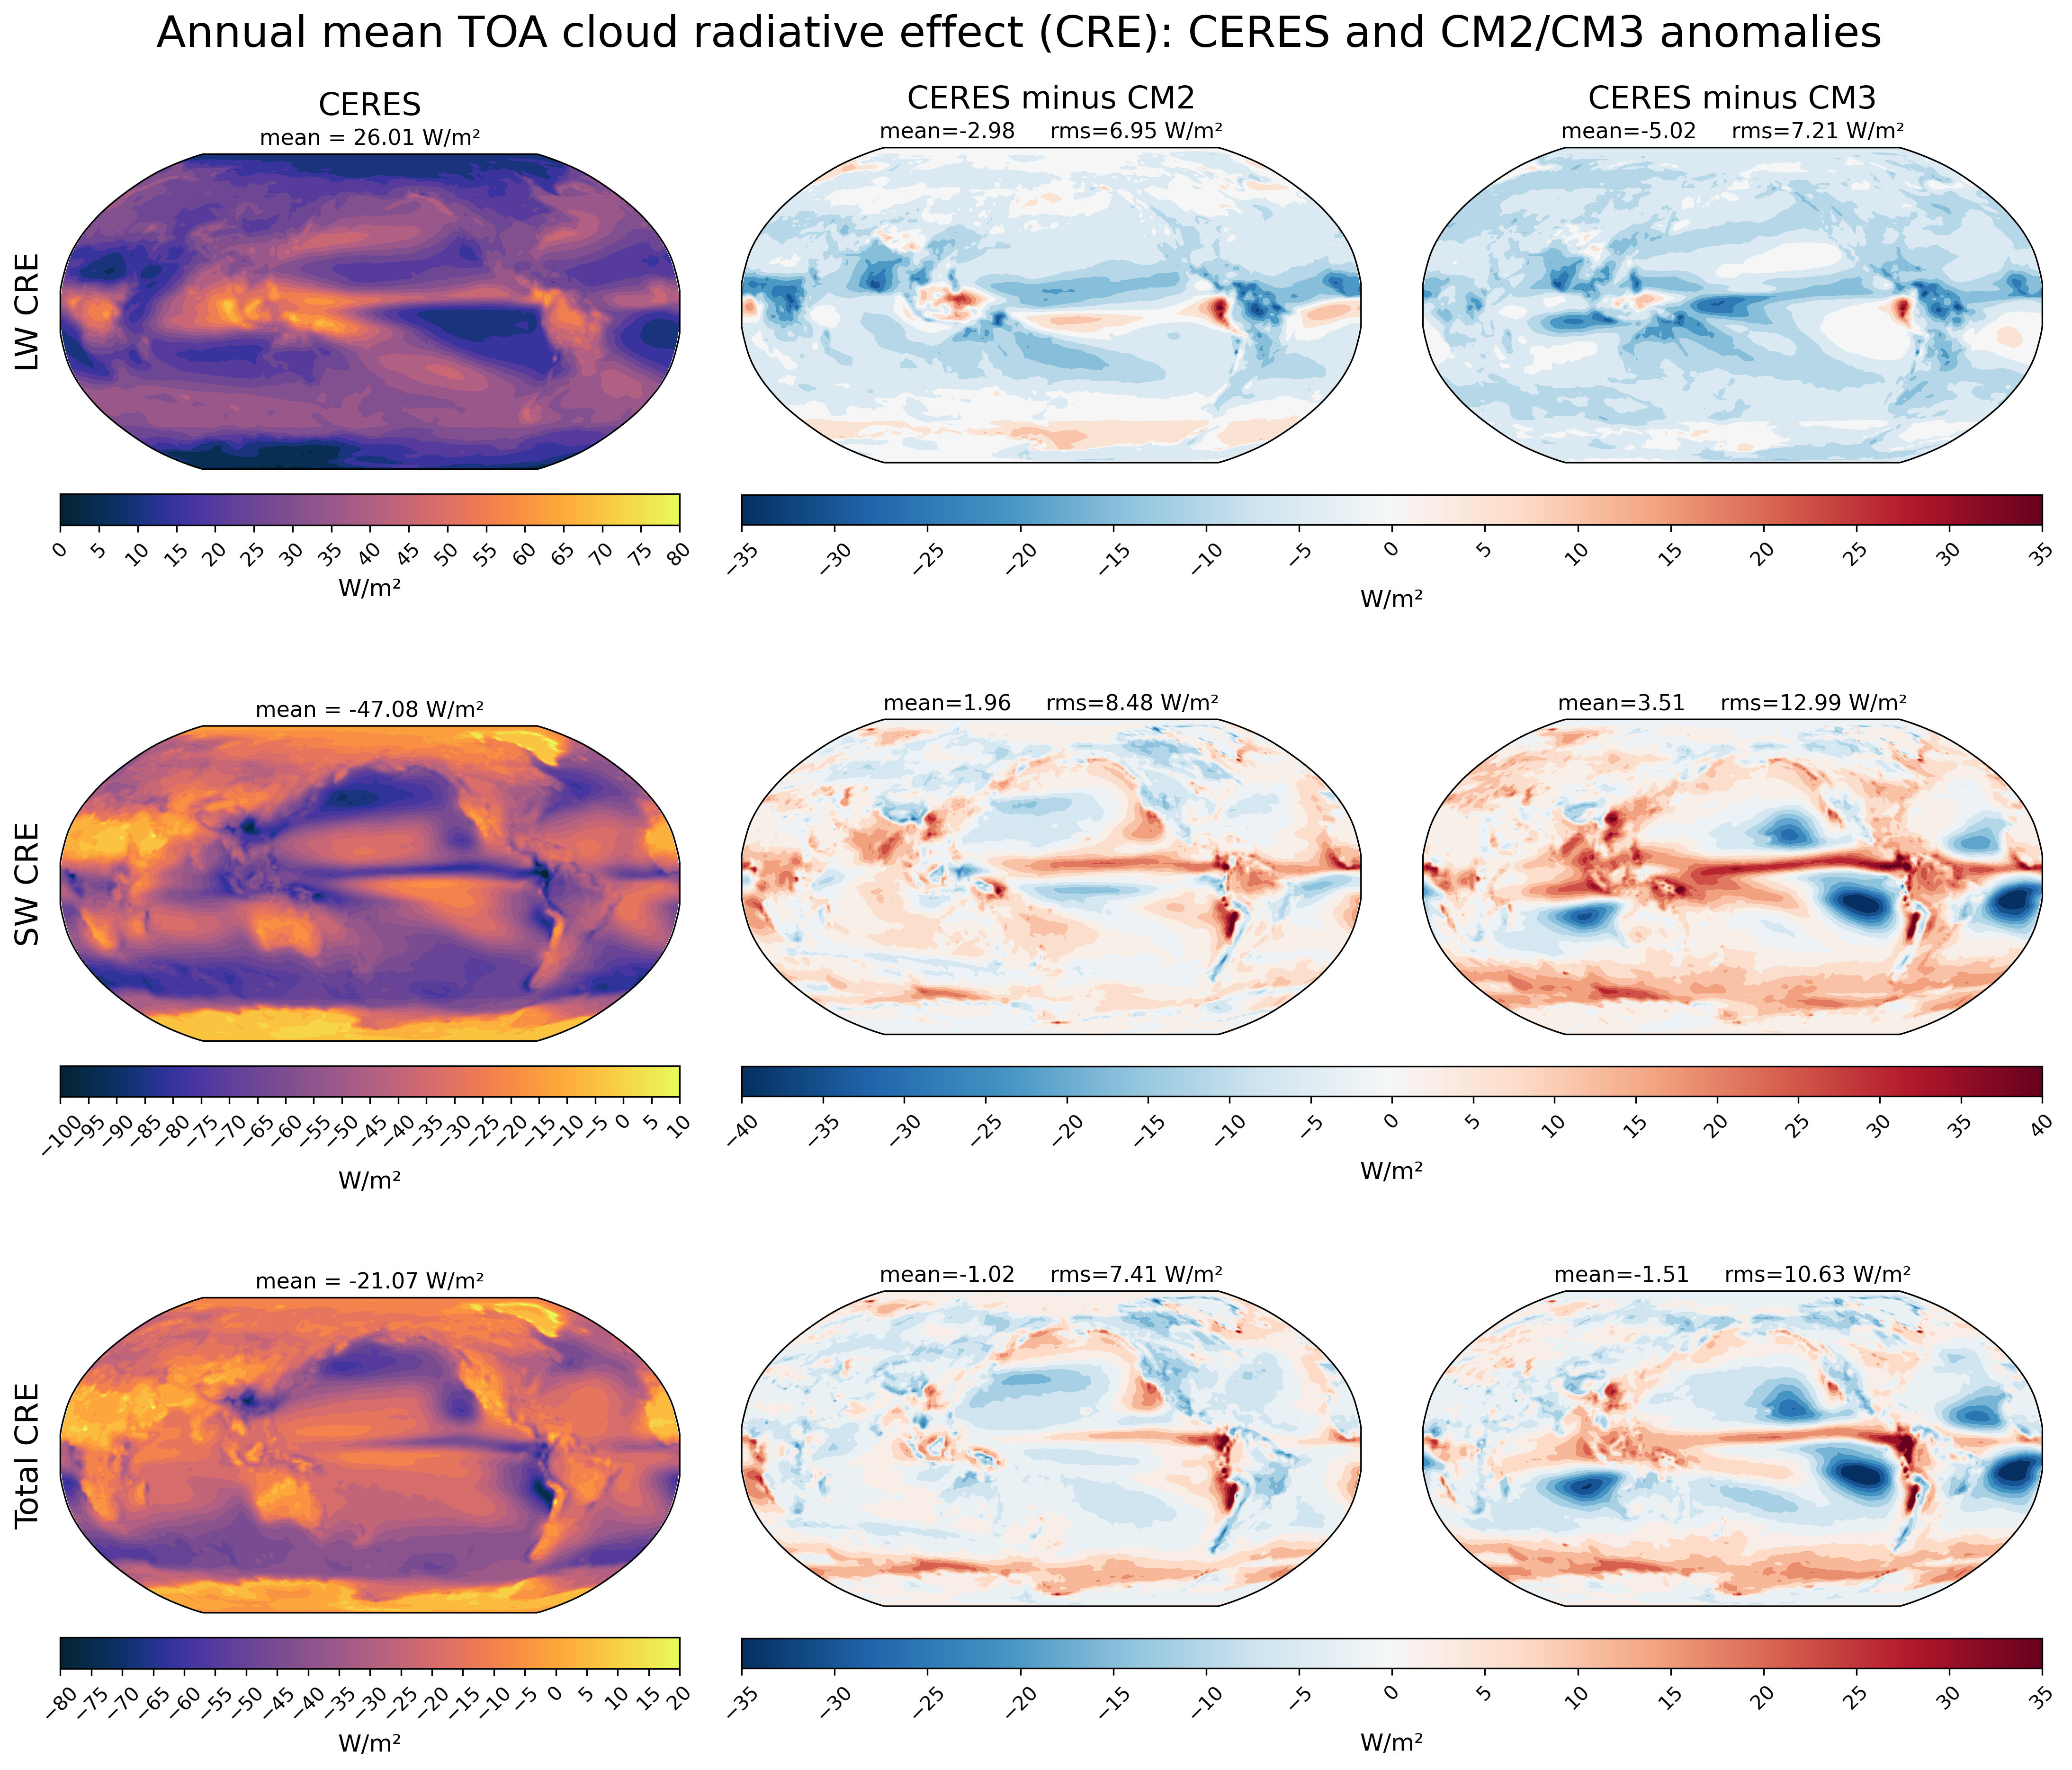

In [197]:
fig = plt.figure(figsize=(18,15))
gs = gridspec.GridSpec(3,3, figure=fig, wspace=0.1, hspace=0.15)

axes = np.empty((3,3), dtype=object)
for i in range(3):
    for j in range(3):
        axes[i,j] = fig.add_subplot(gs[i,j], projection=ccrs.Robinson(central_longitude=180))


row_labels = ["LW CRE", "SW CRE", "Total CRE"]
col_titles = ["CERES", "CERES minus CM2", "CERES minus CM3"]

# Main plotting loop 
for i in range(3):  # rows
    # Column 0: CERES map
    ax = axes[i,0]
    norm = ceres_norms[i]
    levels = np.linspace(norm.vmin, norm.vmax, int((norm.vmax - norm.vmin) // 5) + 1)
    ceres_list[i].plot.contourf(ax=ax, x="lon", y="lat", cmap=ceres_cmaps[i], norm=norm, levels=levels, transform=ccrs.PlateCarree(), add_colorbar=False)
    
    # Add row label
    ax.annotate(row_labels[i], xy=(-0.05, 0.5), xycoords='axes fraction',
                ha='center', va='center', fontsize=16, rotation=90)
    
    # Top row: column title
    if i == 0:
        ax.set_title(col_titles[0], fontsize=16, pad=20)
    
    # Add CERES global mean
    ax.text(0.5, 1.03, f"mean = {ceres_gm[i]:.2f} W/m²",
            ha='center', transform=ax.transAxes, fontsize=11)
    
    # Columns 1 & 2: anomalies CM2 and CM3
    for j, (anom_list, gm_list, rms_list) in enumerate([
        (anom_cm2_list, anom_cm2_gm, anom_cm2_rms),
        (anom_cm3_list, anom_cm3_gm, anom_cm3_rms)
    ]):
        ax2 = axes[i,j+1]
        var_key = ["LW","SW","TOT"][i]
        norm = anom_norm_dict[var_key]
        levels = anom_levels_all[i]
        anom_list[i].plot.contourf(ax=ax2, x="lon", y="lat", cmap=anom_cmap_dict[var_key], norm=norm, levels=levels, transform=ccrs.PlateCarree(), add_colorbar=False)
        # plot_contourf(ax2, anom_list[i], anom_cmap_dict[var_key], anom_norm_dict[var_key])
        
        # Top row: column title
        if i == 0:
            ax2.set_title(col_titles[j+1], fontsize=16, pad=20)
        
        # Mean & RMS
        ax2.text(0.5, 1.03,
                 f"mean={gm_list[i]:.2f}     rms={rms_list[i]:.2f} W/m²",
                 ha='center', transform=ax2.transAxes, fontsize=11)

# Colorbars
# ceres_levels_all = [lw_levels, sw_levels, tot_levels]

# CERES colorbars (individual)
for i in range(3):
    norm = ceres_norms[i]
    levels = np.linspace(norm.vmin, norm.vmax, int((norm.vmax - norm.vmin) // 5) + 1)
    cb = fig.colorbar(
        plt.cm.ScalarMappable(norm=ceres_norms[i], cmap=ceres_cmaps[i]),
        ax=axes[i,0], orientation="horizontal", fraction=0.12, pad=0.05,
        ticks=levels
    )
    height = 0.01
    cb.ax.tick_params(labelsize=10, rotation=45)
    cb.set_label("W/m²", fontsize=12)

# Shared anomaly colorbars (columns 1 & 2)
for i, var in enumerate(["LW","SW","TOT"]):
    left = axes[i,1].get_position().x0
    right = axes[i,2].get_position().x1
    bottom = axes[i,1].get_position().y0 - 0.029
    height = 0.014

    cax = fig.add_axes([left, bottom, right-left, height])
    norm = norm=anom_norm_dict[var]
    levels = anom_levels_all[i]
    cb = fig.colorbar(
        plt.cm.ScalarMappable(norm=norm, cmap=anom_cmap_dict[var]),
        cax=cax, orientation='horizontal',
        ticks=levels
    )
    cb.ax.tick_params(labelsize=10, rotation=45)
    cb.set_label("W/m²", fontsize=12)


fig.suptitle("Annual mean TOA cloud radiative effect (CRE): CERES and CM2/CM3 anomalies",
             fontsize=22, y=.9)
plt.show()